
# Codex MCP + Oracle AI Workflow

This notebook builds a practical Codex CLI workflow around **SQLcl MCP Server**, **Oracle AI Database**, Oracle AI Agent Memory, and optional **LangChain** orchestration.

The architecture separates four responsibilities:

- **Codex CLI** acts as the MCP client and AI agent interface.
- **SQLcl MCP Server** exposes Oracle AI Database operations through an explicit MCP tool contract.
- **Oracle AI Database** stores durable system memory: conversation history, tool traces, retrieval data, and validation checks.
- **LangChain** can wrap retrieval and memory assembly when an application needs repeatable orchestration.

The notebook does not call Codex from Python. In the local Codex CLI + SQLcl MCP pattern, Codex CLI runs the agent experience and spawns SQLcl as a local MCP server process. Python is used here to build and validate the Oracle AI Database memory layer, so the same workflow is inspectable, repeatable, and ready to plug into Codex CLI.


## Architecture at a Glance

```text
                         +--------------------------+
                         |      Human operator      |
                         +------------+-------------+
                                      | asks / reviews
                                      v
+------------------------------------------------------------------+
|                         Codex CLI                                |
|  Intent, planning, conversation continuity, MCP client behavior  |
+------------+---------------------------------------+-------------+
             | Loop A: explicit MCP tool call        | grounded context
             v                                       |
+--------------------------+                         |
|     SQLcl MCP Server     |                         |
|        `sql -mcp`        |                         |
|  saved SQLcl connection  |                         |
+------------+-------------+                         |
             | SQL execution through declared tools  |
             v                                       |
+----------------------------------------------------+-------------+           +------------------------------+        
|                      Oracle AI Database                           |   < ---  |   Oracle AI Agent Memory     |
|  privileges  |  SQL/JSON memory  |  Oracle Text  |  VECTOR search |          |     (Python package)         |
+------------+---------------------------------------+-------------+           +------------------------------+
             | Loop B: durable memory + retrieval    |
             v                                       v
+--------------------------+           +--------------------------+
| Conversation + tool logs |           |   Retrieval evidence     |
| MCP traces, status,      |           |   lexical + vector +     |
| errors, tenant metadata  |           |   metadata filtering     |
+--------------------------+           +------------+-------------+
                                                   | optional wrapper
                                                   v
                                      +--------------------------+
                                      |        LangChain         |
                                      | retrieval orchestration  |
                                      +--------------------------+
```

The important boundary is MCP: Codex CLI does not receive implicit database access. It receives a declared SQLcl MCP tool surface, while Oracle AI Database remains responsible for data access, privileges, durable memory, and retrieval.

This notebook validates the Oracle AI Database memory and retrieval layer directly, then prepares the artifacts needed for live Codex MCP validation: the MCP config preview, the SQLcl saved-connection check, and the manual Codex CLI test.


## What You Will Learn

- How Codex CLI uses SQLcl MCP as an explicit Oracle AI Database tool boundary.
- How to generate and validate the Codex MCP configuration artifacts.
- How to store Codex/MCP conversation traces, tool logs, and retrieval memory in Oracle AI Database.
- How to classify MCP tool calls before they are treated as safe to execute.
- How to run lexical search, vector search, and hybrid retrieval over the same memory layer.
- How to create evidence packages and LangChain-compatible documents from Oracle AI Database memory.


## Workflow Overview

1. Validate the local Codex CLI + SQLcl MCP setup path.
2. Generate the Codex `config.toml` MCP config preview.
3. Create Oracle AI Database memory tables.
4. Insert a realistic Codex + MCP workflow.
5. Inspect tool traces and controlled failures.
6. Run lexical, vector, and hybrid retrieval.
7. Visualize retrieval scores and MCP tool decisions.
8. Generate Codex-ready evidence and prompt artifacts.
9. Wrap retrieval with LangChain.
10. End with a compact validation snapshot.


## Prerequisites

You should have:

- Python 3.10+
- Oracle AI Database access
- `oracledb`, `python-dotenv`, `pandas`, `numpy`, and `matplotlib` packages installed
- Oracle SQLcl 25.2+ for SQLcl MCP workflows
- Oracle JRE 17 or 21 for SQLcl MCP workflows
- Codex CLI if you want to use the generated MCP configuration outside this notebook
- A saved SQLcl connection for MCP usage, ideally created with `-savepwd`

Optional integration packages:
- `oracleagentmemory` package (Step 15 - Oracle AI Agent Memory)
- `langchain-core`, `langchain`, `langchain-community`, and `langchain-oracledb` packages (Step 16 - LangChain)

The install cell below installs the base packages first, then attempts the optional integration packages separately. If optional packages are unavailable, the core Oracle AI Database memory workflow can still run.

The Python part of this notebook uses the values in `.env`:

```env
ORACLE_USER=
ORACLE_PASSWORD=
ORACLE_DSN=
SQLCL_PATH=
SQLCL_CONNECTION_NAME=codex_mcp
CODEX_CONFIG_PATH=
TNS_ADMIN=
OPENAI_API_KEY=
```

`OPENAI_API_KEY` is loaded so the environment is ready for OpenAI-backed Codex workflows. The notebook demo itself uses deterministic local embeddings by default, so it does not require OpenAI API calls or model billing.

Keep `SQLCL_PATH` empty if `sql` / `sql.exe` is already available on your `PATH`.


In [146]:
# Install dependencies (safe to re-run)
import sys
import subprocess
from pathlib import Path


def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "requirements.txt").exists() and (candidate / ".env").exists():
            return candidate
    return start


PROJECT_ROOT = find_project_root(Path.cwd())
requirements_path = PROJECT_ROOT / "requirements.txt"

base_packages = [
    "oracledb",
    "python-dotenv",
    "pandas",
    "numpy",
    "matplotlib",
    "ipykernel",
]
optional_packages = [
    "oracleagentmemory",
    "langchain",
    "langchain-core",
    "langchain-community",
    "langchain-oracledb",
]


def pip_install(packages: list[str], label: str):
    command = [sys.executable, "-m", "pip", "install", "-q", *packages]
    result = subprocess.run(command, capture_output=True, text=True)
    if result.returncode != 0 and "Read-only file system" in (result.stderr or ""):
        result = subprocess.run(command + ["--user"], capture_output=True, text=True)
    if result.returncode != 0:
        print(f"{label} installation failed. Last pip messages:")
        print((result.stderr or result.stdout)[-2000:])
    return result


base_result = pip_install(base_packages, "Base dependency")
if base_result.returncode != 0:
    raise RuntimeError("Base dependency installation failed.")

print("Base dependencies installed.")

optional_result = pip_install(optional_packages, "Optional dependency")
if optional_result.returncode != 0:
    print("Optional packages could not be installed. LangChain and Oracle AI Agent Memory sections will run in optional/fallback mode.")
else:
    print("Optional dependencies installed.")

if requirements_path.exists():
    print("requirements.txt found at:", requirements_path)


Base dependencies installed.
Optional dependencies installed.
requirements.txt found at: /Users/srinidhi/Downloads/claude_mcp_oracle_ai_database_1/requirements.txt


## Configuration

This section loads `.env`, masks sensitive values, and keeps notebook paths stable whether you launch Jupyter from the project root or from the `notebooks` folder.


In [147]:
import os
import json
import platform
from pathlib import Path
from dotenv import load_dotenv
import pandas as pd
import matplotlib.pyplot as plt


def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / ".env").exists() and (candidate / "requirements.txt").exists():
            return candidate
    return start


PROJECT_ROOT = find_project_root(Path.cwd())
NOTEBOOK_DIR = PROJECT_ROOT / "notebooks"
ENV_PATH = PROJECT_ROOT / ".env"

load_dotenv(ENV_PATH, override=True)
print("Loaded .env from:", ENV_PATH)

CONFIG = {
    "ORACLE_USER": os.getenv("ORACLE_USER", "").strip(),
    "ORACLE_PASSWORD": os.getenv("ORACLE_PASSWORD", ""),
    "ORACLE_DSN": os.getenv("ORACLE_DSN", "").strip(),
    "SQLCL_PATH": os.getenv("SQLCL_PATH", "").strip(),
    "SQLCL_CONNECTION_NAME": os.getenv("SQLCL_CONNECTION_NAME", "codex_mcp").strip() or "codex_mcp",
    "CODEX_CONFIG_PATH": os.getenv("CODEX_CONFIG_PATH", "").strip(),
    "TNS_ADMIN": os.getenv("TNS_ADMIN", "").strip(),
    "OPENAI_API_KEY": os.getenv("OPENAI_API_KEY", "").strip(),
}

config_readiness = pd.DataFrame([
    {"setting": "Oracle AI Database credentials", "status": "READY" if CONFIG["ORACLE_USER"] and CONFIG["ORACLE_PASSWORD"] and CONFIG["ORACLE_DSN"] else "ACTION_NEEDED", "public_value": "<loaded from .env>"},
    {"setting": "SQLcl executable", "status": "CONFIGURED" if CONFIG["SQLCL_PATH"] else "AUTO_DETECT", "public_value": "<SQLCL_PATH set>" if CONFIG["SQLCL_PATH"] else "<search PATH>"},
    {"setting": "SQLcl saved connection alias", "status": "READY", "public_value": CONFIG["SQLCL_CONNECTION_NAME"]},
    {"setting": "Codex config path", "status": "DEFAULT" if not CONFIG["CODEX_CONFIG_PATH"] else "CONFIGURED", "public_value": "<default ~/.codex/config.toml>" if not CONFIG["CODEX_CONFIG_PATH"] else "<custom path set>"},
    {"setting": "TNS_ADMIN", "status": "OPTIONAL" if not CONFIG["TNS_ADMIN"] else "CONFIGURED", "public_value": "<not set>" if not CONFIG["TNS_ADMIN"] else "<configured>"},
    {"setting": "OpenAI API key", "status": "CONFIGURED" if CONFIG["OPENAI_API_KEY"] else "ACTION_NEEDED", "public_value": "<loaded from .env>"},
])

print("Configuration readiness matrix")
display(config_readiness)


Loaded .env from: /Users/srinidhi/Downloads/claude_mcp_oracle_ai_database_1/.env
Configuration readiness matrix


,setting,status,public_value
0,Oracle AI Database credentials,READY,<loaded from .env>
1,SQLcl executable,CONFIGURED,<SQLCL_PATH set>
2,SQLcl saved connection alias,READY,codex_mcp
3,Codex config path,DEFAULT,<default ~/.codex/config.toml>
4,TNS_ADMIN,OPTIONAL,<not set>
5,OpenAI API key,CONFIGURED,<loaded from .env>


## Step 1 - Validate the SQLcl MCP Environment

Codex CLI starts SQLcl as an MCP server by launching `sql -mcp`. This cell does **not** start the MCP server, because an MCP server is a long-running process. Instead, it checks whether SQLcl and Java are discoverable and captures their readiness.

If the SQLcl row says `ACTION_NEEDED`, that does not mean the Oracle AI Database memory workflow failed. It means live Codex MCP validation still needs standalone SQLcl configured through `SQLCL_PATH`.

If SQLcl is not on `PATH`, set `SQLCL_PATH` in `.env` to the full path of standalone SQLcl, for example:

```env
SQLCL_PATH=C:\tools\sqlcl\bin\sql.exe
```


In [148]:
import shutil
import subprocess
from pathlib import Path


def run_process(command, timeout=15, input_text=None):
    try:
        completed = subprocess.run(
            command,
            capture_output=True,
            text=True,
            timeout=timeout,
            shell=False,
            input=input_text,
        )
        output = (completed.stdout or "") + (completed.stderr or "")
        return {
            "ok": completed.returncode == 0,
            "returncode": completed.returncode,
            "output": output.strip(),
            "error": None,
        }
    except Exception as exc:
        return {
            "ok": False,
            "returncode": None,
            "output": "",
            "error": str(exc),
        }


def resolve_sqlcl(sqlcl_path: str):
    if sqlcl_path:
        candidate = Path(sqlcl_path)
        if candidate.exists():
            return str(candidate)
        return sqlcl_path
    return shutil.which("sqlcl") or shutil.which("sqlcl.exe") or shutil.which("sql") or shutil.which("sql.exe")


def looks_like_usable_sqlcl(check: dict) -> bool:
    output = (check.get("output") or "") + (check.get("error") or "")
    if not check.get("ok"):
        return False
    return "SQLcl" in output or "Oracle SQLDeveloper Command-Line" in output


def summarize_sqlcl_issue(check: dict) -> str:
    detail = (check.get("output") or check.get("error") or "").lower()
    if "noclassdeffounderror" in detail or "unable to initialize main class" in detail:
        return "Detected a sql executable that is not a standalone SQLcl MCP runtime. Set SQLCL_PATH to standalone SQLcl."
    if "not found" in detail or not SQLCL_EXECUTABLE:
        return "SQLcl was not found. Install standalone SQLcl 25.2+ and set SQLCL_PATH."
    if not check.get("ok"):
        return "SQLcl version check failed. Validate SQLcl installation and Java runtime."
    return "SQLcl version output did not match the expected SQLcl signature."


SQLCL_EXECUTABLE = resolve_sqlcl(CONFIG["SQLCL_PATH"])
sqlcl_check = run_process([SQLCL_EXECUTABLE, "-version"]) if SQLCL_EXECUTABLE else {
    "ok": False,
    "returncode": None,
    "output": "",
    "error": "SQLcl executable was not found. Set SQLCL_PATH or add SQLcl to PATH.",
}
SQLCL_MCP_READY = looks_like_usable_sqlcl(sqlcl_check)
java_check = run_process(["java", "-version"])

java_first_line = (java_check["output"] or "").splitlines()[0] if java_check["ok"] and java_check["output"] else "Java runtime was not validated."

mcp_runtime_report = pd.DataFrame([
    {
        "check": "Standalone SQLcl for MCP",
        "status": "READY" if SQLCL_MCP_READY else "ACTION_NEEDED",
        "evidence": "SQLcl version validated." if SQLCL_MCP_READY else summarize_sqlcl_issue(sqlcl_check),
        "next_step": "Use this executable in Codex config." if SQLCL_MCP_READY else "Install standalone SQLcl 25.2+ and set SQLCL_PATH.",
    },
    {
        "check": "Java runtime",
        "status": "READY" if java_check["ok"] else "ACTION_NEEDED",
        "evidence": java_first_line,
        "next_step": "No action." if java_check["ok"] else "Install Oracle JRE 17 or 21.",
    },
    {
        "check": "MCP launch mode",
        "status": "READY" if SQLCL_MCP_READY else "PENDING",
        "evidence": "`sql -mcp` will be used by Codex CLI.",
        "next_step": "Restart Codex CLI or open a new terminal session after config change." if SQLCL_MCP_READY else "Complete SQLcl validation first.",
    },
])

display(mcp_runtime_report)


,check,status,evidence,next_step
0,Standalone SQLcl for MCP,READY,SQLcl version validated.,Use this executable in Codex config.
1,Java runtime,READY,"openjdk version ""21.0.11"" 2026-04-21",No action.
2,MCP launch mode,READY,`sql -mcp` will be used by Codex CLI.,Restart Codex CLI or open a new terminal sessi...


## Step 2 - Generate a Codex MCP Config Preview

Codex stores MCP server configuration in `config.toml`. By default this is `~/.codex/config.toml`, and trusted projects can also use `.codex/config.toml` for project-scoped configuration.

For SQLcl MCP, the important part is:


```toml
[mcp_servers.sqlcl]
command = "PATH_TO_SQLCL"
args = ["-mcp"]
```

This notebook writes a **preview** file into the project folder. It does not overwrite your real Codex config. That keeps the workflow safe and reviewable.


In [149]:
from pathlib import Path
import json
import os


def default_codex_config_path() -> Path:
    return Path.home() / ".codex" / "config.toml"


def toml_quote(value: str) -> str:
    return json.dumps(value)


command_for_config = SQLCL_EXECUTABLE if SQLCL_MCP_READY else (CONFIG["SQLCL_PATH"] or "PATH_TO_STANDALONE_SQLCL_BIN_SQL_EXE")
toml_lines = [
    "[mcp_servers.sqlcl]",
    f"command = {toml_quote(command_for_config)}",
    "args = [\"-mcp\"]",
]

if CONFIG["TNS_ADMIN"]:
    toml_lines.extend([
        "",
        "[mcp_servers.sqlcl.env]",
        f"TNS_ADMIN = {toml_quote(CONFIG['TNS_ADMIN'])}",
    ])

mcp_config_toml = "\n".join(toml_lines) + "\n"
preview_path = PROJECT_ROOT / "codex_sqlcl_mcp_config.preview.toml"
preview_path.write_text(mcp_config_toml, encoding="utf-8")

safe_config_toml = mcp_config_toml
if command_for_config != "PATH_TO_STANDALONE_SQLCL_BIN_SQL_EXE":
    safe_config_toml = safe_config_toml.replace(toml_quote(command_for_config), toml_quote("<STANDALONE_SQLCL_EXECUTABLE>"), 1)

config_artifact = {
    "artifact": "Codex MCP server config preview",
    "server_name": "sqlcl",
    "launch_command": "sql -mcp",
    "preview_file": "codex_sqlcl_mcp_config.preview.toml",
    "config_target": str(Path(CONFIG["CODEX_CONFIG_PATH"]) if CONFIG["CODEX_CONFIG_PATH"] else default_codex_config_path()),
    "ready_for_copy": bool(SQLCL_MCP_READY),
}

print(json.dumps(config_artifact, indent=2))
print("\nSanitized MCP server TOML:")
print(safe_config_toml)


{
  "artifact": "Codex MCP server config preview",
  "server_name": "sqlcl",
  "launch_command": "sql -mcp",
  "preview_file": "codex_sqlcl_mcp_config.preview.toml",
  "config_target": "/Users/srinidhi/.codex/config.toml",
  "ready_for_copy": true
}

Sanitized MCP server TOML:
[mcp_servers.sqlcl]
command = "<STANDALONE_SQLCL_EXECUTABLE>"
args = ["-mcp"]



## Step 2b - Saved SQLcl Connection Check

SQLcl MCP uses SQLcl's connection store instead of inventing database connections dynamically. For an MCP-compatible connection, save the connection and persist the password with `-savepwd`.

This cell prints a safe template and validates the configured saved connection alias by launching SQLcl with `-name <alias>`. That is the same saved-connection path Codex CLI relies on when SQLcl MCP starts locally. The cell does not print your real password.


In [150]:
from pathlib import Path

connection_name = CONFIG["SQLCL_CONNECTION_NAME"]

connection_contract = {
    "connection_alias": connection_name,
    "connection_store": "~/.dbtools",
    "password_requirement_for_mcp": "Use -savepwd for MCP-compatible saved connections.",
    "recommended_role": "read-only validation role first; expand scopes only after review.",
}

print("SQLcl saved connection contract:")
print(json.dumps(connection_contract, indent=2))
print("\nTemplate to run in SQLcl after confirming credentials:")
print(f"conn -save {connection_name} -savepwd <ORACLE_USER>/<ORACLE_PASSWORD>@<ORACLE_DSN>")

if SQLCL_MCP_READY:
    sqlcl_connection_check = run_process(
        [SQLCL_EXECUTABLE, "-s", "-name", connection_name],
        timeout=25,
        input_text="SELECT USER FROM dual;\nexit\n",
    )
    sqlcl_connection_output = (sqlcl_connection_check.get("output") or "") + (sqlcl_connection_check.get("error") or "")
    SQLCL_CONNECTION_READY = sqlcl_connection_check["ok"] and CONFIG["ORACLE_USER"].upper() in sqlcl_connection_output.upper()
else:
    sqlcl_connection_check = {
        "ok": False,
        "returncode": None,
        "output": "",
        "error": "SQLcl runtime is not ready, so the saved connection alias was not tested.",
    }
    sqlcl_connection_output = sqlcl_connection_check["error"]
    SQLCL_CONNECTION_READY = False

sqlcl_connection_lines = [line.strip() for line in sqlcl_connection_output.splitlines() if line.strip()]
sqlcl_connection_evidence = (
    f"Saved alias connected as {CONFIG['ORACLE_USER'].upper()}."
    if SQLCL_CONNECTION_READY
    else (sqlcl_connection_lines[-1] if sqlcl_connection_lines else "No SQLcl connection output was returned.")
)

connection_validation = pd.DataFrame([
    {
        "check": "Saved SQLcl connection alias",
        "value": connection_name,
        "status": "READY" if SQLCL_CONNECTION_READY else "ACTION_NEEDED",
        "detail": "SQLcl saved alias connected successfully." if SQLCL_CONNECTION_READY else "Saved alias did not connect through SQLcl -name.",
        "evidence": sqlcl_connection_evidence,
        "next_step": "No action." if SQLCL_CONNECTION_READY else "Run the template above with -savepwd, then rerun this cell.",
    }
])

display_df(connection_validation)


SQLcl saved connection contract:
{
  "connection_alias": "codex_mcp",
  "connection_store": "~/.dbtools",
  "password_requirement_for_mcp": "Use -savepwd for MCP-compatible saved connections.",
  "recommended_role": "read-only validation role first; expand scopes only after review."
}

Template to run in SQLcl after confirming credentials:
conn -save codex_mcp -savepwd <ORACLE_USER>/<ORACLE_PASSWORD>@<ORACLE_DSN>


,check,value,status,detail,evidence,next_step
0,Saved SQLcl connection alias,codex_mcp,ACTION_NEEDED,Saved alias did not connect through SQLcl -name.,at oracle.dbtools.raptor.scriptrunner.cmdline....,"Run the template above with -savepwd, then rer..."


## Step 2c - Manual Check: Validate SQLcl MCP in Codex CLI

This notebook cannot drive your Codex CLI session from inside Jupyter, so this section is intentionally a manual check. It connects the notebook workflow to the real Codex CLI MCP workflow.

Use this checklist after `SQLCL_PATH` points to standalone SQLcl and the saved connection alias is `READY`:

1. Save an MCP-compatible SQLcl connection with `-savepwd`.
2. Add the SQLcl MCP server to Codex `config.toml` using `[mcp_servers.sqlcl]` and `args = ["-mcp"]`.
3. Restart Codex CLI or open a new terminal session so the MCP server configuration is reloaded.
4. In Codex CLI, run `/mcp` and confirm the SQLcl MCP server and tools are listed.

Ask Codex CLI:

```text
Use the SQLcl MCP tools to list available saved connections. Do not run DML or DDL.
```

Expected result: Codex CLI discovers SQLcl MCP tools, SQLcl uses saved connection profiles, and Oracle AI Database privileges decide what can be read or changed.


## Step 3 - Connect to Oracle AI Database from Python

The MCP loop is operational: Codex CLI calls SQLcl tools. The notebook loop is persistence-oriented: Python creates and queries the Oracle memory substrate.

This connection is used to create the demo memory tables and retrieval workflow.


In [151]:
import oracledb

required = ["ORACLE_USER", "ORACLE_PASSWORD", "ORACLE_DSN"]
missing = [key for key in required if not CONFIG[key]]
if missing:
    raise RuntimeError(f"Missing required Oracle settings in .env: {missing}")

connection = oracledb.connect(
    user=CONFIG["ORACLE_USER"],
    password=CONFIG["ORACLE_PASSWORD"],
    dsn=CONFIG["ORACLE_DSN"],
)
connection.autocommit = False
cursor = connection.cursor()

db_version = connection.version
current_user = cursor.execute("SELECT USER FROM dual").fetchone()[0]

print("Connected to Oracle AI Database successfully.")

Connected to Oracle AI Database successfully.


## Helper Utilities

These helpers keep the notebook readable and safe to rerun.


In [152]:
import re
import json
import pandas as pd
from typing import Any


def lob_to_text(value: Any) -> Any:
    if hasattr(value, "read"):
        return value.read()
    return value


def rows_to_dataframe(cursor_obj, rows):
    columns = [col[0].lower() for col in cursor_obj.description] if cursor_obj.description else []
    normalized_rows = [
        [lob_to_text(value) for value in row]
        for row in rows
    ]
    return pd.DataFrame(normalized_rows, columns=columns)


def run_sql(sql: str, params: dict | None = None, fetch: bool = True, commit: bool = False) -> pd.DataFrame | None:
    cursor.execute(sql, params or {})
    if commit:
        connection.commit()
    if fetch and cursor.description:
        return rows_to_dataframe(cursor, cursor.fetchall())
    return None


def is_safe_name(name: str) -> bool:
    return bool(re.fullmatch(r"[A-Za-z][A-Za-z0-9_]{0,127}", name))


def execute_ddl(sql: str):
    cursor.execute(sql)
    connection.commit()


def safe_drop_table(table_name: str, verbose: bool = False):
    if not is_safe_name(table_name):
        raise ValueError(f"Unsafe table name: {table_name}")
    try:
        execute_ddl(f"DROP TABLE {table_name} PURGE")
        if verbose:
            print(f"Dropped table: {table_name}")
    except oracledb.DatabaseError as exc:
        error_obj = exc.args[0]
        if getattr(error_obj, "code", None) == 942:
            if verbose:
                print(f"Table did not exist: {table_name}")
        else:
            raise


def safe_drop_index(index_name: str, verbose: bool = False):
    if not is_safe_name(index_name):
        raise ValueError(f"Unsafe index name: {index_name}")
    try:
        execute_ddl(f"DROP INDEX {index_name}")
        if verbose:
            print(f"Dropped index: {index_name}")
    except oracledb.DatabaseError as exc:
        error_obj = exc.args[0]
        if getattr(error_obj, "code", None) in [1418, 942]:
            if verbose:
                print(f"Index did not exist: {index_name}")
        else:
            raise


def display_df(df: pd.DataFrame, empty_message: str = "No rows returned."):
    if df is None or df.empty:
        print(empty_message)
    else:
        display(df)



def plot_bar(df: pd.DataFrame, x: str, y: str, title: str, color: str = "#2f6f73"):
    if df is None or df.empty:
        print(f"No data to plot for: {title}")
        return
    ax = df.plot(kind="barh", x=x, y=y, legend=False, figsize=(8, max(3, len(df) * 0.45)), color=color)
    ax.set_title(title)
    ax.set_xlabel(y)
    ax.set_ylabel("")
    ax.invert_yaxis()
    for container in ax.containers:
        ax.bar_label(container, fmt="%.2f", padding=3)
    plt.tight_layout()
    plt.show()


def plot_mcp_policy_heatmap(df: pd.DataFrame):
    if df is None or df.empty:
        print("No MCP policy data to plot.")
        return
    decision_weight = {
        "ALLOW": 1,
        "REQUIRE_CONFIRMATION": 2,
        "BLOCK_IN_READONLY_MODE": 3,
    }
    risk_weight = {"LOW": 1, "LOW_TO_MEDIUM": 2, "HIGH": 3, "CRITICAL": 4, "UNKNOWN": 4}
    matrix = df[["tool_name", "risk", "decision"]].copy()
    matrix["risk_weight"] = matrix["risk"].map(risk_weight).fillna(4)
    matrix["decision_weight"] = matrix["decision"].map(decision_weight).fillna(3)
    plot_values = matrix[["risk_weight", "decision_weight"]].to_numpy()

    fig, ax = plt.subplots(figsize=(8, max(3, len(matrix) * 0.55)))
    image = ax.imshow(plot_values, cmap="YlOrRd", aspect="auto", vmin=1, vmax=4)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["risk", "decision"])
    ax.set_yticks(range(len(matrix)))
    ax.set_yticklabels(matrix["tool_name"])
    ax.set_title("MCP tool contract heatmap")

    for row in range(plot_values.shape[0]):
        ax.text(0, row, matrix.iloc[row]["risk"], ha="center", va="center", fontsize=8)
        ax.text(1, row, matrix.iloc[row]["decision"], ha="center", va="center", fontsize=8)

    fig.colorbar(image, ax=ax, fraction=0.03, pad=0.04)
    plt.tight_layout()
    plt.show()


def plot_vector_lollipop(df: pd.DataFrame):
    if df is None or df.empty:
        print("No vector search data to plot.")
        return
    plot_df = df.sort_values("vector_score", ascending=True).copy()
    y_positions = range(len(plot_df))
    fig, ax = plt.subplots(figsize=(8, max(3, len(plot_df) * 0.5)))
    ax.hlines(y=y_positions, xmin=0, xmax=plot_df["vector_score"], color="#9fb7c9", linewidth=2)
    ax.scatter(plot_df["vector_score"], y_positions, color="#2d5f8b", s=90)
    ax.set_yticks(list(y_positions))
    ax.set_yticklabels(plot_df["title"])
    ax.set_xlim(0, max(1.0, float(plot_df["vector_score"].max()) + 0.05))
    ax.set_xlabel("vector_score")
    ax.set_title("Vector search score distribution")
    for y, score in zip(y_positions, plot_df["vector_score"]):
        ax.text(score + 0.02, y, f"{score:.2f}", va="center")
    plt.tight_layout()
    plt.show()


def plot_hybrid_signal_mix(query: str, tenant_id: str = "TENANT_A", top_k: int = 5):
    lexical = lexical_search(query, tenant_id=tenant_id, top_k=top_k).copy()
    semantic = vector_search(query, tenant_id=tenant_id, top_k=top_k).copy()
    if lexical.empty or semantic.empty:
        print("Not enough data to plot hybrid signal mix.")
        return

    lexical["lexical_norm"] = normalize_series(lexical["lexical_score"].astype(float))
    semantic["vector_norm"] = normalize_series(semantic["vector_score"].astype(float))
    merged = pd.merge(
        lexical[["chunk_id", "title", "lexical_norm"]],
        semantic[["chunk_id", "vector_norm"]],
        on="chunk_id",
        how="outer",
    ).fillna(0)
    merged["combined"] = merged["lexical_norm"] + merged["vector_norm"]
    merged = merged.sort_values("combined", ascending=True).tail(top_k)

    fig, ax = plt.subplots(figsize=(8, max(3, len(merged) * 0.5)))
    ax.barh(merged["title"], merged["lexical_norm"], label="lexical", color="#c27c4b")
    ax.barh(merged["title"], merged["vector_norm"], left=merged["lexical_norm"], label="vector", color="#4f7f9f")
    ax.set_title("Hybrid retrieval signal mix")
    ax.set_xlabel("normalized contribution")
    ax.legend(loc="lower right")
    plt.tight_layout()
    plt.show()


def plot_evidence_radar(df: pd.DataFrame, title: str = "Evidence profile"):
    if df is None or df.empty:
        print("No evidence data to plot.")
        return
    category_scores = df.groupby("category")["hybrid_score"].max().sort_values(ascending=False)
    labels = list(category_scores.index)
    values = category_scores.to_numpy(dtype=float)
    values = values / values.max() if values.max() else values

    angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False)
    values_closed = np.concatenate([values, values[:1]])
    angles_closed = np.concatenate([angles, angles[:1]])

    fig = plt.figure(figsize=(6, 6))
    ax = fig.add_subplot(111, polar=True)
    ax.plot(angles_closed, values_closed, color="#6f5f90", linewidth=2)
    ax.fill(angles_closed, values_closed, color="#6f5f90", alpha=0.20)
    ax.set_xticks(angles)
    ax.set_xticklabels(labels)
    ax.set_yticklabels([])
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

## Step 4 - Define MCP Tool Policy

The most important technical point in this notebook is that MCP should make tool access explicit. Codex should not behave as if it has invisible database access. Each operation should be represented as a tool call with a known boundary.

This cell creates a simple policy gate that classifies tool calls before execution:

- discovery calls are allowed,
- bounded read-only SQL is allowed,
- write-like requests require confirmation,
- destructive requests are blocked in read-only mode,
- memory retrieval remains tenant-scoped.

Oracle AI Database privileges are still the real enforcement layer. The policy gate is here to make the notebook's MCP behavior visible before any live tool execution happens.


MCP tool contract gate:


,tool_name,risk,decision,read_only,confirmation_required,control_status,reason
0,sqlcl.connections/list_connections,LOW,ALLOW,True,False,SAFE,Read-only or discovery operation.
1,sqlcl.sql/query,LOW_TO_MEDIUM,ALLOW,True,False,SAFE,Read-only or discovery operation.
2,sqlcl.sql/query,LOW_TO_MEDIUM,REQUIRE_CONFIRMATION,True,True,CONTROLLED,Write-capable operation detected.
3,sqlcl.sql/execute_ddl,CRITICAL,BLOCK_IN_READONLY_MODE,False,True,CONTROLLED,Destructive or DDL-like operation detected.
4,oracle_memory/retrieve,LOW,ALLOW,True,False,SAFE,Read-only or discovery operation.


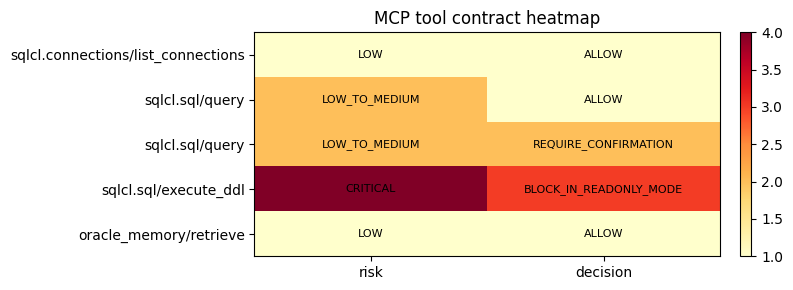

In [153]:
MCP_TOOL_POLICY = {
    "sqlcl.connections/list_connections": {
        "readOnlyHint": True,
        "destructiveHint": False,
        "requiresConfirmation": False,
        "risk": "LOW",
        "purpose": "Discover saved SQLcl connection aliases.",
    },
    "sqlcl.sql/query": {
        "readOnlyHint": True,
        "destructiveHint": False,
        "requiresConfirmation": False,
        "risk": "LOW_TO_MEDIUM",
        "purpose": "Run bounded SELECT statements through SQLcl MCP.",
    },
    "sqlcl.sql/execute_dml": {
        "readOnlyHint": False,
        "destructiveHint": False,
        "requiresConfirmation": True,
        "risk": "HIGH",
        "purpose": "Data-changing operations require confirmation and scoped privileges.",
    },
    "sqlcl.sql/execute_ddl": {
        "readOnlyHint": False,
        "destructiveHint": True,
        "requiresConfirmation": True,
        "risk": "CRITICAL",
        "purpose": "DDL operations require explicit approval and elevated privileges.",
    },
    "oracle_memory/retrieve": {
        "readOnlyHint": True,
        "destructiveHint": False,
        "requiresConfirmation": False,
        "risk": "LOW",
        "purpose": "Retrieve tenant-scoped Oracle AI Database memory.",
    },
}


def classify_mcp_tool_call(tool_name: str, sql_summary: str = "") -> dict:
    policy = MCP_TOOL_POLICY.get(tool_name, {
        "readOnlyHint": False,
        "destructiveHint": True,
        "requiresConfirmation": True,
        "risk": "UNKNOWN",
        "purpose": "Unknown tool; require review before use.",
    })
    lowered = f" {sql_summary.lower()} "
    write_terms = [" insert ", " update ", " delete ", " merge "]
    destructive_terms = [" drop ", " truncate ", " alter ", " grant ", " revoke "]
    write_detected = any(term in lowered for term in write_terms)
    destructive_detected = any(term in lowered for term in destructive_terms)

    decision = "ALLOW"
    reason = "Read-only or discovery operation."
    if policy["requiresConfirmation"] or write_detected:
        decision = "REQUIRE_CONFIRMATION"
        reason = "Write-capable operation detected."
    if policy["destructiveHint"] or destructive_detected:
        decision = "BLOCK_IN_READONLY_MODE"
        reason = "Destructive or DDL-like operation detected."

    return {
        "tool_name": tool_name,
        "risk": policy["risk"],
        "decision": decision,
        "read_only": policy["readOnlyHint"],
        "confirmation_required": policy["requiresConfirmation"] or write_detected or destructive_detected,
        "control_status": "SAFE" if decision == "ALLOW" else "CONTROLLED",
        "reason": reason,
    }


policy_examples = pd.DataFrame([
    classify_mcp_tool_call("sqlcl.connections/list_connections"),
    classify_mcp_tool_call("sqlcl.sql/query", "select owner, table_name from all_tables fetch first 10 rows only"),
    classify_mcp_tool_call("sqlcl.sql/query", "update support_jobs set reviewed = 'Y'"),
    classify_mcp_tool_call("sqlcl.sql/execute_ddl", "drop table old_memory"),
    classify_mcp_tool_call("oracle_memory/retrieve", "retrieve tenant scoped MCP setup memory"),
])

print("MCP tool contract gate:")
display_df(policy_examples)

plot_mcp_policy_heatmap(policy_examples)


**DEVELOPER PATTERN: MCP tool gate**

Use this when: You want to inspect or log what tool class a request falls into before execution.

Minimal call: `classify_mcp_tool_call("sqlcl.sql/query", "select ...")`

Expected output: dict with `risk`, `decision`, `confirmation_required`

Adapt for your app: Extend `MCP_TOOL_POLICY` with your own tool names and risk levels.

Production note: This gate is observability, not enforcement. Real enforcement stays in Oracle privileges.


## Step 5 - Create Oracle AI Database-Backed Memory Tables

The article separates memory into three practical categories:

- **Conversational memory**: user and assistant turns.
- **Operational memory**: MCP tool calls, inputs, outputs, status, and errors.
- **Semantic memory**: reusable knowledge chunks and embeddings.

The table names are prefixed with `CODEX_` so the demo is easy to identify and clean up.


In [154]:
RESET_DEMO = True

TABLES = [
    "CODEX_VALIDATION_CHECKS",
    "CODEX_KB_CHUNKS",
    "CODEX_TOOL_LOGS",
    "CODEX_CONVERSATIONAL_MEMORY",
]

DDL = {
    "codex_conversational_memory": """
        CREATE TABLE codex_conversational_memory (
            memory_id      NUMBER GENERATED ALWAYS AS IDENTITY PRIMARY KEY,
            tenant_id      VARCHAR2(64) NOT NULL,
            thread_id      VARCHAR2(128) NOT NULL,
            role           VARCHAR2(32) NOT NULL,
            content        CLOB NOT NULL,
            metadata_json  CLOB CHECK (metadata_json IS JSON),
            created_at     TIMESTAMP DEFAULT SYSTIMESTAMP NOT NULL
        )
    """,
    "codex_tool_logs": """
        CREATE TABLE codex_tool_logs (
            log_id         NUMBER GENERATED ALWAYS AS IDENTITY PRIMARY KEY,
            tenant_id      VARCHAR2(64) NOT NULL,
            thread_id      VARCHAR2(128) NOT NULL,
            tool_name      VARCHAR2(200) NOT NULL,
            tool_input     CLOB CHECK (tool_input IS JSON),
            tool_output    CLOB CHECK (tool_output IS JSON),
            status         VARCHAR2(32) NOT NULL,
            error_class    VARCHAR2(80),
            error_message  VARCHAR2(1000),
            created_at     TIMESTAMP DEFAULT SYSTIMESTAMP NOT NULL
        )
    """,
    "codex_kb_chunks": """
        CREATE TABLE codex_kb_chunks (
            chunk_id        NUMBER GENERATED ALWAYS AS IDENTITY PRIMARY KEY,
            tenant_id       VARCHAR2(64) NOT NULL,
            source_name     VARCHAR2(200) NOT NULL,
            category        VARCHAR2(80) NOT NULL,
            title           VARCHAR2(300) NOT NULL,
            chunk_text      CLOB NOT NULL,
            metadata_json   CLOB CHECK (metadata_json IS JSON),
            embedding_json  CLOB CHECK (embedding_json IS JSON),
            created_at      TIMESTAMP DEFAULT SYSTIMESTAMP NOT NULL
        )
    """,
    "codex_validation_checks": """
        CREATE TABLE codex_validation_checks (
            check_id       NUMBER GENERATED ALWAYS AS IDENTITY PRIMARY KEY,
            check_name     VARCHAR2(120) NOT NULL,
            status         VARCHAR2(32) NOT NULL,
            detail         VARCHAR2(1000),
            created_at     TIMESTAMP DEFAULT SYSTIMESTAMP NOT NULL
        )
    """,
}

if RESET_DEMO:
    safe_drop_index("CODEX_KB_TEXT_IDX")
    safe_drop_index("CODEX_KB_VECTOR_IDX")
    for table in TABLES:
        safe_drop_table(table)

for statement in DDL.values():
    execute_ddl(statement)

print("Oracle AI Database memory schema ready.")

Oracle AI Database memory schema ready.


## Step 6 - Insert a Sample Codex + MCP Workflow

These records are simulated teaching data. They show what an operational workflow should preserve, but they are not live SQLcl MCP telemetry captured from Codex CLI:

- what the user asked,
- what Codex planned,
- what MCP tool calls were attempted,
- which calls succeeded or failed,
- and what memory should be available later.

This is the key difference between assistant memory and system memory: the database gives us something queryable, auditable, and shareable across sessions.


In [155]:
SCENARIO = "support-job investigation"

conversation_rows = [
    ("TENANT_A", "thread-codex-mcp-001", "user",
     "Can you inspect failed jobs from the Oracle support schema and summarize what changed since yesterday?",
     {"client": "Codex CLI", "loop": "operational", "memory_type": "conversation"}),
    ("TENANT_A", "thread-codex-mcp-001", "assistant",
     "I will use SQLcl MCP tools to list connections, run a bounded read-only query, and summarize with evidence.",
     {"client": "Codex CLI", "loop": "operational", "planned_boundary": "SQLcl MCP"}),
    ("TENANT_A", "thread-codex-mcp-001", "assistant",
     "The investigation found two failed jobs: one permission issue and one stale index maintenance job.",
     {"client": "Codex CLI", "loop": "grounded_response", "sources": ["codex_tool_logs"]}),
    ("TENANT_B", "thread-codex-mcp-002", "user",
     "Show the onboarding validation checklist for MCP connections.",
     {"client": "Codex CLI", "loop": "operational", "memory_type": "conversation"}),
]

tool_log_rows = [
    ("TENANT_A", "thread-codex-mcp-001", "sqlcl.connections/list_connections",
     {"requested_by": "Codex CLI"},
     {"connections": [CONFIG["SQLCL_CONNECTION_NAME"]], "selected": CONFIG["SQLCL_CONNECTION_NAME"]},
     "SUCCESS", None, None),
    ("TENANT_A", "thread-codex-mcp-001", "sqlcl.sql/query",
     {"connection": CONFIG["SQLCL_CONNECTION_NAME"], "sql_summary": "select failed jobs with bounded result set"},
     {"rows": 2, "columns": ["job_name", "status", "error_code", "last_run"]},
     "SUCCESS", None, None),
    ("TENANT_A", "thread-codex-mcp-001", "sqlcl.sql/query",
     {"connection": CONFIG["SQLCL_CONNECTION_NAME"], "sql_summary": "attempted write to mark job reviewed"},
     {"rows": 0},
     "DENIED", "PRIVILEGE_SCOPE", "Read-only role blocked a write operation. This is expected in validation mode."),
    ("TENANT_A", "thread-codex-mcp-001", "oracle_memory/retrieve",
     {"query": "MCP saved connection setup", "top_k": 3},
     {"rows": 3, "quality": "usable"},
     "SUCCESS", None, None),
    ("TENANT_B", "thread-codex-mcp-002", "oracle_memory/retrieve",
     {"query": "onboarding validation checklist for MCP connections", "top_k": 3},
     {"rows": 1, "quality": "weak"},
     "WARNING", "RETRIEVAL_QUALITY", "Only one tenant-scoped memory chunk matched the query."),
]

try:
    cursor.executemany(
        """INSERT INTO codex_conversational_memory
            (tenant_id, thread_id, role, content, metadata_json)
        VALUES (:1, :2, :3, :4, :5)""",
        [(tenant, thread, role, content, json.dumps(metadata))
         for tenant, thread, role, content, metadata in conversation_rows],
    )
    cursor.executemany(
        """INSERT INTO codex_tool_logs
            (tenant_id, thread_id, tool_name, tool_input, tool_output, status, error_class, error_message)
        VALUES (:1, :2, :3, :4, :5, :6, :7, :8)""",
        [(tenant, thread, tool, json.dumps(tool_input), json.dumps(tool_output), status, error_class, error_message)
         for tenant, thread, tool, tool_input, tool_output, status, error_class, error_message in tool_log_rows],
    )
    connection.commit()
except Exception as exc:
    connection.rollback()
    raise RuntimeError(f"Step 6 insert failed and was rolled back: {exc}") from exc

memory_load_summary = pd.DataFrame([
    {"memory_stream": "conversational_memory", "rows_loaded": len(conversation_rows), "purpose": "Codex/user turns and grounded responses"},
    {"memory_stream": "operational_tool_logs", "rows_loaded": len(tool_log_rows), "purpose": "MCP tool call audit trail"},
])
display_df(memory_load_summary)


,memory_stream,rows_loaded,purpose
0,conversational_memory,4,Codex/user turns and grounded responses
1,operational_tool_logs,5,MCP tool call audit trail


## Step 7 - Query Operational Memory

These queries are where the workflow becomes auditable. Instead of asking "why did the assistant answer that way?", we can inspect the execution trail:

- which MCP tools ran,
- which tenant/thread they belonged to,
- which operations failed,
- and whether failures were expected privilege boundaries or real runtime issues.


In [156]:
tool_status = run_sql("""
SELECT
    tenant_id,
    tool_name,
    status,
    COUNT(*) AS calls
FROM codex_tool_logs
GROUP BY tenant_id, tool_name, status
ORDER BY tenant_id, tool_name, status
""")

status_order = {"SUCCESS": 1, "WARNING": 2, "DENIED": 3, "ERROR": 4}
tool_status["status_rank"] = tool_status["status"].map(status_order).fillna(99)
tool_status = tool_status.sort_values(["tenant_id", "status_rank", "tool_name"]).drop(columns=["status_rank"])
tool_status["control_status"] = tool_status["status"].map({
    "SUCCESS": "OK",
    "DENIED": "CONTROLLED",
    "WARNING": "REVIEW",
    "ERROR": "ACTION_NEEDED",
}).fillna("REVIEW")

print("MCP operational call matrix:")
display_df(tool_status)


MCP operational call matrix:


,tenant_id,tool_name,status,calls,control_status
0,TENANT_A,oracle_memory/retrieve,SUCCESS,1,OK
1,TENANT_A,sqlcl.connections/list_connections,SUCCESS,1,OK
3,TENANT_A,sqlcl.sql/query,SUCCESS,1,OK
2,TENANT_A,sqlcl.sql/query,DENIED,1,CONTROLLED
4,TENANT_B,oracle_memory/retrieve,WARNING,1,REVIEW


In [157]:
thread_timeline = run_sql("""
SELECT
    'CONVERSATION' AS event_kind,
    tenant_id,
    thread_id,
    role AS actor,
    DBMS_LOB.SUBSTR(content, 220, 1) AS summary,
    created_at
FROM codex_conversational_memory
WHERE thread_id = :thread_id
UNION ALL
SELECT
    'MCP_TOOL' AS event_kind,
    tenant_id,
    thread_id,
    tool_name AS actor,
    status || CASE WHEN error_class IS NOT NULL THEN ' / ' || error_class ELSE '' END AS summary,
    created_at
FROM codex_tool_logs
WHERE thread_id = :thread_id
ORDER BY created_at, event_kind
""", {"thread_id": "thread-codex-mcp-001"})

thread_timeline.insert(0, "step", range(1, len(thread_timeline) + 1))
thread_timeline["created_at"] = pd.to_datetime(thread_timeline["created_at"]).dt.strftime("%H:%M:%S")

print("Single-thread Codex MCP execution timeline:")
display_df(thread_timeline)

Single-thread Codex MCP execution timeline:


,step,event_kind,tenant_id,thread_id,actor,summary,created_at
0,1,CONVERSATION,TENANT_A,thread-codex-mcp-001,assistant,The investigation found two failed jobs: one p...,18:59:23
1,2,CONVERSATION,TENANT_A,thread-codex-mcp-001,assistant,I will use SQLcl MCP tools to list connections...,18:59:23
2,3,CONVERSATION,TENANT_A,thread-codex-mcp-001,user,Can you inspect failed jobs from the Oracle su...,18:59:23
3,4,MCP_TOOL,TENANT_A,thread-codex-mcp-001,sqlcl.sql/query,DENIED / PRIVILEGE_SCOPE,18:59:24
4,5,MCP_TOOL,TENANT_A,thread-codex-mcp-001,sqlcl.sql/query,SUCCESS,18:59:24
5,6,MCP_TOOL,TENANT_A,thread-codex-mcp-001,oracle_memory/retrieve,SUCCESS,18:59:24
6,7,MCP_TOOL,TENANT_A,thread-codex-mcp-001,sqlcl.connections/list_connections,SUCCESS,18:59:24


In [158]:
audit_view = run_sql("""
SELECT
    tenant_id,
    thread_id,
    tool_name,
    status,
    error_class,
    error_message,
    created_at
FROM codex_tool_logs
WHERE status <> 'SUCCESS'
ORDER BY created_at DESC
""")

if not audit_view.empty:
    audit_view["control_status"] = audit_view["error_class"].map({
        "PRIVILEGE_SCOPE": "CONTROLLED",
        "RETRIEVAL_QUALITY": "REVIEW",
    }).fillna("ACTION_NEEDED")
    audit_view["control_interpretation"] = audit_view["error_class"].map({
        "PRIVILEGE_SCOPE": "Expected boundary: read-only mode blocked a write attempt.",
        "RETRIEVAL_QUALITY": "Retrieval quality signal captured for review.",
    }).fillna("Review required.")
    audit_view["created_at"] = pd.to_datetime(audit_view["created_at"]).dt.strftime("%H:%M:%S")

print("Controlled review signals:")
display_df(audit_view, "No non-success tool calls found.")


Controlled review signals:


,tenant_id,thread_id,tool_name,status,error_class,error_message,created_at,control_status,control_interpretation
0,TENANT_B,thread-codex-mcp-002,oracle_memory/retrieve,WARNING,RETRIEVAL_QUALITY,Only one tenant-scoped memory chunk matched th...,18:59:24,REVIEW,Retrieval quality signal captured for review.
1,TENANT_A,thread-codex-mcp-001,sqlcl.sql/query,DENIED,PRIVILEGE_SCOPE,Read-only role blocked a write operation. This...,18:59:24,CONTROLLED,Expected boundary: read-only mode blocked a wr...


## Step 8 - Insert Knowledge Memory

These chunks represent the durable memory that should outlive a single Codex CLI session. They are written as tenant-scoped chunks so retrieval can enforce boundaries. In a production workflow, this is the layer Oracle AI Agent Memory manages through its package API. You are building it manually here so the structure is fully visible.

The notebook uses deterministic demo embeddings later, so no external embedding service or API key is required.


In [159]:
knowledge_rows = [
    ("mcp_setup", "SQLcl MCP execution boundary",
     "Codex CLI should connect to Oracle AI Database through SQLcl MCP using sql -mcp. The assistant calls explicit tools instead of receiving unrestricted database access.",
     "Setup Guide", "high"),
    ("mcp_setup", "Saved SQLcl connections for MCP",
     "SQLcl MCP relies on saved SQLcl connection profiles stored under the user connection store. MCP-compatible connections should persist the password with savepwd so Codex CLI can launch the server reproducibly.",
     "Setup Guide", "high"),
    ("security", "Least privilege first",
     "Operational rollout should start with read-only database roles, schema allowlists, and explicit confirmation workflows for high-impact write operations.",
     "Engineering guidance", "high"),
    ("observability", "Tool logging baseline",
     "Log the tool name, thread ID, tenant ID, timestamp, status, and sanitized input and output summaries for every MCP tool call.",
     "Engineering guidance", "high"),
    ("langchain", "LangChain as orchestration glue",
     "LangChain is useful for declaring retrievers and composing retrieval-first pipelines, but security enforcement should stay in database privileges and runtime boundaries.",
     "Where LangChain adds value", "medium"),
    ("retrieval", "Retrieval quality failure mode",
     "Fluent but weakly grounded answers usually point to poor chunking, sparse metadata, weak retrieval settings, or a corpus that no longer matches real query patterns.",
     "Failure modes", "medium"),
    ("memory_model", "Codex memory versus Oracle memory",
     "Codex memory improves assistant continuity, while Oracle memory provides durable, queryable, governed system memory across users, sessions, and tools.",
     "Codex memory vs Oracle memory", "high"),
]

tenant_b_row = (
    "TENANT_B", "tenant_b_validation", "mcp_setup", "Tenant B onboarding note",
    "Tenant B allows read-only SQLcl MCP onboarding only after the connection alias is reviewed by the platform team.",
    {"article_section": "Tenant validation", "priority": "medium"},
)

insert_rows = [
    ("TENANT_A", "codex_mcp_oracle_ai_database_article", category, title, text,
     {"article_section": section, "priority": priority})
    for category, title, text, section, priority in knowledge_rows
] + [tenant_b_row]

try:
    cursor.executemany(
        """
        INSERT INTO codex_kb_chunks
            (tenant_id, source_name, category, title, chunk_text, metadata_json)
        VALUES (:1, :2, :3, :4, :5, :6)
        """,
        [(tenant, source, category, title, text, json.dumps(metadata))
        for tenant, source, category, title, text, metadata in insert_rows],
    )

    connection.commit()
except Exception as exc:
    connection.rollback()
    raise RuntimeError(f"Step 7 insert failed and was rolled back: {exc}") from exc

print(f"Inserted {len(insert_rows)} knowledge chunks.")

Inserted 8 knowledge chunks.


### Where We Are

The operational and audit layer is now in place:

- SQLcl MCP boundary has been validated (or flagged for local setup).
- Oracle AI Database memory tables exist and are populated with simulated Codex/MCP traces.
- Tool call outcomes, including controlled failures, are stored and queryable.

The notebook now shifts to the retrieval and grounding layer: lexical search, vector search, hybrid retrieval, and assembling evidence packages for the assistant.
